In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (necesario para proyeccion 3d)
from sklearn.linear_model import LinearRegression



In [13]:
from regresion_lineal_gd import ajustar_regresion_lineal, hipotesis, funcion_costo, gradiente_descendente

In [2]:
# ---------------------------------------------------------------------------
# Funciones base: hipotesis y funcion de costo
# ---------------------------------------------------------------------------
def hipotesis(theta0, theta1, X):
    """h_theta(x) = theta0 + theta1 * x"""
    return theta0 + theta1 * X


def funcion_costo(theta0, theta1, X, Y):
    """J(theta0, theta1) = (1 / 2m) * sum((h(x) - y)^2)"""
    m = len(X)
    pred = hipotesis(theta0, theta1, X)
    error = pred - Y
    return (1 / (2 * m)) * np.sum(error**2)



In [3]:
# ---------------------------------------------------------------------------
# Gradiente descendente generico (para una funcion f(w) cualquiera)
# ---------------------------------------------------------------------------
def gradiente_descendente_1d(f, df, w0, alpha, epsilon=1e-4, max_iter=10000):
    """
    Minimiza f(w) mediante gradiente descendente en 1 dimension.
    Devuelve el w encontrado y el historial de valores.
    """
    w = w0
    historia = [w]
    for _ in range(max_iter):
        w_nuevo = w - alpha * df(w)
        historia.append(w_nuevo)
        if abs(w_nuevo - w) < epsilon:
            w = w_nuevo
            break
        w = w_nuevo
    return w, historia


def gradiente_descendente_2d(dFx, dFy, x0, y0, alpha, epsilon=1e-4, max_iter=10000):
    """
    Minimiza F(x, y) mediante gradiente descendente en 2 dimensiones,
    dadas las derivadas parciales dFx = dF/dx y dFy = dF/dy.
    """
    x, y = x0, y0
    for _ in range(max_iter):
        x_nuevo = x - alpha * dFx(x, y)
        y_nuevo = y - alpha * dFy(x, y)
        if np.hypot(x_nuevo - x, y_nuevo - y) < epsilon:
            x, y = x_nuevo, y_nuevo
            break
        x, y = x_nuevo, y_nuevo
    return x, y


def gradiente_descendente_regresion(X, Y, alpha=0.5, epsilon=1e-6, max_iter=100000):
    """
    Gradiente descendente especifico para el modelo de regresion lineal
    h(x) = theta0 + theta1 * x, minimizando J(theta0, theta1).
    """
    theta0, theta1 = 0.0, 0.0
    m = len(X)
    for _ in range(max_iter):
        pred = hipotesis(theta0, theta1, X)
        error = pred - Y
        grad0 = (1 / m) * np.sum(error)
        grad1 = (1 / m) * np.sum(error * X)
        theta0_nuevo = theta0 - alpha * grad0
        theta1_nuevo = theta1 - alpha * grad1
        if abs(theta0_nuevo - theta0) < epsilon and abs(theta1_nuevo - theta1) < epsilon:
            theta0, theta1 = theta0_nuevo, theta1_nuevo
            break
        theta0, theta1 = theta0_nuevo, theta1_nuevo
    return theta0, theta1



In [4]:
# ---------------------------------------------------------------------------
# Punto 1: DataFrame con datos lineales
# ---------------------------------------------------------------------------
theta0_real, theta1_real = 2.0, 3.0
X = np.linspace(0, 10, 50)
Y = theta0_real + theta1_real * X

df = pd.DataFrame({"X": X, "Y": Y})
print(df.head())



          X         Y
0  0.000000  2.000000
1  0.204082  2.612245
2  0.408163  3.224490
3  0.612245  3.836735
4  0.816327  4.448980


In [5]:
# ---------------------------------------------------------------------------
# Punto 2:
# ---------------------------------------------------------------------------
def hipotesis(theta0, theta1, X):
    return theta0 + theta1 * X

def funcion_costo(theta0, theta1, X, Y):
    m = len(X)
    pred = hipotesis(theta0, theta1, X)
    error = pred - Y
    return (1 / (2 * m)) * np.sum(error**2)



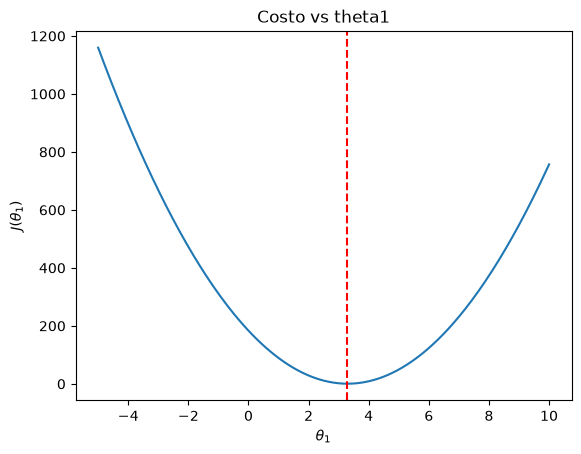

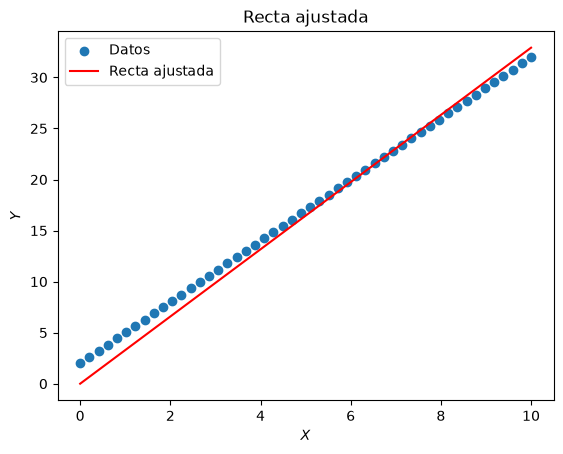

In [6]:
# ---------------------------------------------------------------------------
# Punto 3: barrido de theta1 con theta0 = 0 fijo
# ---------------------------------------------------------------------------
theta0_fijo = 0
thetas1 = np.linspace(-5, 10, 200)
costos = [funcion_costo(theta0_fijo, t1, X, Y) for t1 in thetas1]
theta1_optimo = thetas1[np.argmin(costos)]

plt.figure()
plt.plot(thetas1, costos)
plt.axvline(theta1_optimo, color="red", linestyle="--")
plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$J(\theta_1)$")
plt.title("Costo vs theta1")
plt.show()

plt.figure()
plt.scatter(X, Y, label="Datos")
plt.plot(X, hipotesis(theta0_fijo, theta1_optimo, X), color="red", label="Recta ajustada")
plt.xlabel(r"$X$")
plt.ylabel(r"$Y$")
plt.title("Recta ajustada")
plt.legend()
plt.show()



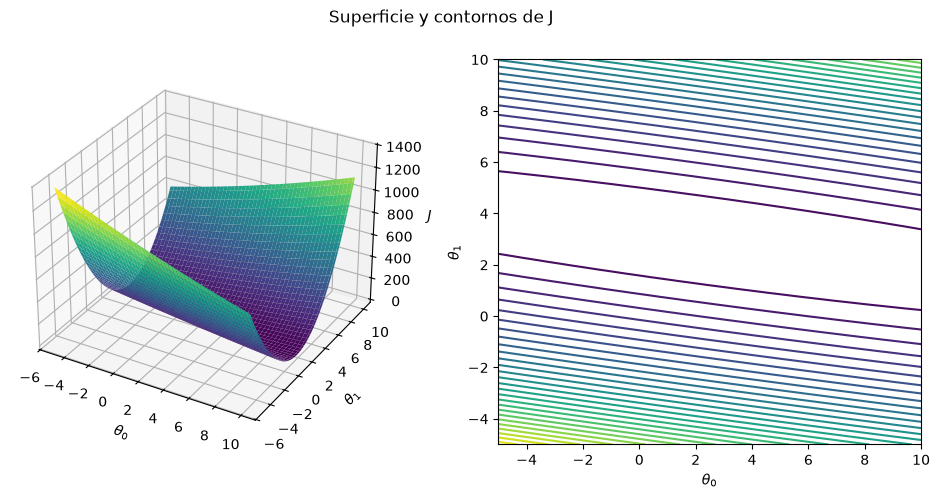

In [7]:
# ---------------------------------------------------------------------------
# Puntos 4-5: superficie y curvas de nivel de J(theta0, theta1)
# ---------------------------------------------------------------------------
t0_vals = np.linspace(-5, 10, 100)
t1_vals = np.linspace(-5, 10, 100)
T0, T1 = np.meshgrid(t0_vals, t1_vals)

J_vals = np.zeros_like(T0)
for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        J_vals[i, j] = funcion_costo(T0[i, j], T1[i, j], X, Y)

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot_surface(T0, T1, J_vals, cmap="viridis")
ax1.set_xlabel(r"$\theta_0$")
ax1.set_ylabel(r"$\theta_1$")
ax1.set_zlabel(r"$J$")

ax2 = fig.add_subplot(1, 2, 2)
ax2.contour(T0, T1, J_vals, levels=30, cmap="viridis")
ax2.set_xlabel(r"$\theta_0$")
ax2.set_ylabel(r"$\theta_1$")
plt.suptitle("Superficie y contornos de J")
plt.show()


→Para regresión lineal con error cuadrático, J es una función cuadrática convexa en Θ. 
→ La superficie es un "paraboloide" y las curvas de nivel son elipses concéntricas alrededor de un único mínimo global (no hay mínimos locales espurios). El error es cuadrático justamente por esto, garantiza la convexidad de la superficie en torno a un único punto (que es justamente el mínimo, el valor de parámetros de los Θ que minimiza el coste).

In [8]:
# ---------------------------------------------------------------------------
# Punto 6: datos con ruido
# ---------------------------------------------------------------------------
np.random.seed(0)
Y_ruido = theta0_real + theta1_real * X + np.random.normal(0, 2, size=len(X))
df2 = pd.DataFrame({"X": X, "Y": Y_ruido})
print(df2.head())


          X         Y
0  0.000000  5.528105
1  0.204082  3.412559
2  0.408163  5.181966
3  0.612245  8.318521
4  0.816327  8.184096


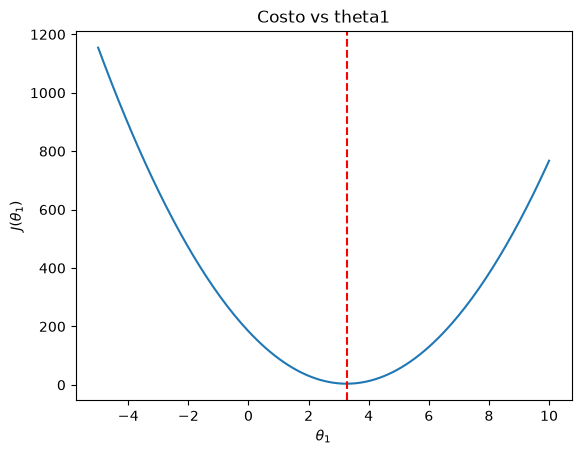

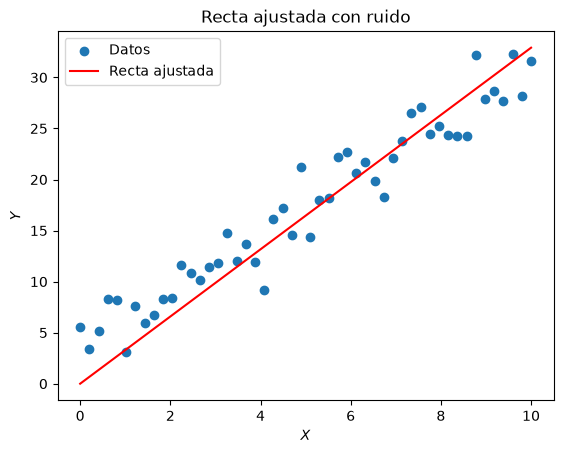

In [ ]:
# ---------------------------------------------------------------------------
# Barrido de theta1 con theta0 = 0 fijo con Y_ruido
# ---------------------------------------------------------------------------
theta0_fijo = 0
thetas1 = np.linspace(-5, 10, 200)
costos = [funcion_costo(theta0_fijo, t1, X, Y_ruido) for t1 in thetas1]
theta1_optimo = thetas1[np.argmin(costos)]

plt.figure()
plt.plot(thetas1, costos)
plt.axvline(theta1_optimo, color="red", linestyle="--")
plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$J(\theta_1)$")
plt.title("Costo vs theta1 con ruido")
plt.show()

plt.figure()
plt.scatter(X, Y_ruido, label="Datos")
plt.plot(X, hipotesis(theta0_fijo, theta1_optimo, X), color="red", label="Recta ajustada")
plt.xlabel(r"$X$")
plt.ylabel(r"$Y$")
plt.title("Recta ajustada con ruido")
plt.legend()
plt.show()



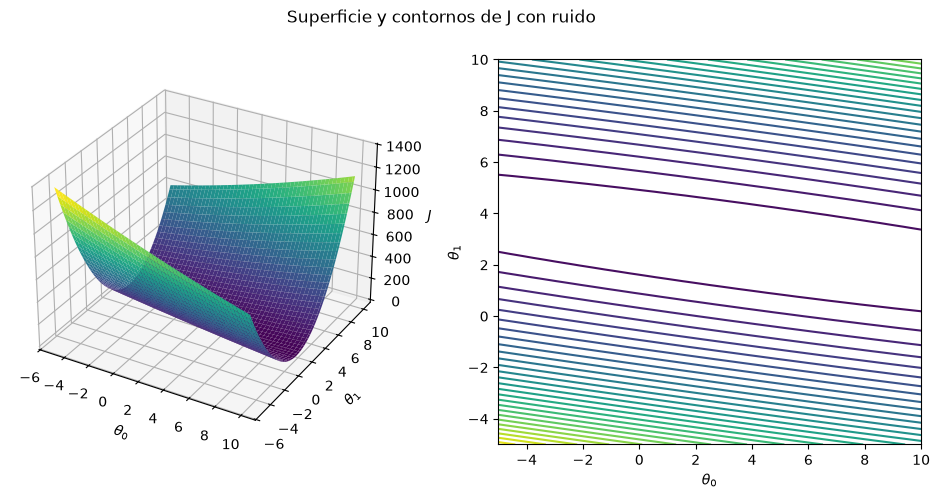

In [20]:
# ---------------------------------------------------------------------------
# Superficie y curvas de nivel de J(theta0, theta1) con ruido
# ---------------------------------------------------------------------------
t0_vals = np.linspace(-5, 10, 100)
t1_vals = np.linspace(-5, 10, 100)
T0, T1 = np.meshgrid(t0_vals, t1_vals)

J_vals = np.zeros_like(T0)
for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        J_vals[i, j] = funcion_costo(T0[i, j], T1[i, j], X, Y_ruido)

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot_surface(T0, T1, J_vals, cmap="viridis")
ax1.set_xlabel(r"$\theta_0$")
ax1.set_ylabel(r"$\theta_1$")
ax1.set_zlabel(r"$J$")

ax2 = fig.add_subplot(1, 2, 2)
ax2.contour(T0, T1, J_vals, levels=30, cmap="viridis")
ax2.set_xlabel(r"$\theta_0$")
ax2.set_ylabel(r"$\theta_1$")
plt.suptitle("Superficie y contornos de J con ruido")
plt.show()


### Comparación del mínimo y la forma de \(J\) entre los casos ideal y con ruido

En el caso ideal, los datos se generan exactamente mediante:

\[
Y = 2 + 3X
\]

Por ello, existe una solución que ajusta todos los puntos perfectamente:

\[
\theta_0 = 2,\qquad \theta_1 = 3
\]

En este punto, el error de predicción es cero para todas las observaciones, por lo que:

\[
J(2,3)=0
\]

La superficie de \(J(\theta_0,\theta_1)\) tiene forma paraboloide convexa y su mínimo global se encuentra exactamente en \((2,3)\). Las curvas de nivel son elipses concéntricas alrededor de ese punto.

En el caso con ruido, los datos se generan como:

\[
Y_{\text{ruido}} = 2 + 3X + \varepsilon
\]

donde \(\varepsilon\) representa el ruido aleatorio. Como los puntos ya no están exactamente sobre la recta original, ningún par de parámetros puede producir error cero para todas las observaciones. Por tanto, el mínimo cumple:

\[
J(\theta_0^*,\theta_1^*) > 0
\]

Además, el mínimo se desplaza ligeramente respecto a \((2,3)\), debido a la influencia del ruido sobre los datos. Sin embargo, sigue siendo un mínimo global único.

La forma general de \(J\) no cambia: continúa siendo una función cuadrática convexa, con una superficie paraboloide y curvas de nivel elípticas. Como los valores de \(X\) son los mismos en ambos casos, la curvatura y la orientación de estas curvas son prácticamente iguales. El ruido modifica principalmente la posición del mínimo y eleva el valor mínimo del costo.

En conclusión, el caso ideal permite recuperar exactamente los parámetros reales y obtener un costo cero. En cambio, el ruido produce un ajuste aproximado, aumenta el costo mínimo y desplaza ligeramente los parámetros óptimos, pero no elimina la convexidad ni el mínimo global de la función.

In [ ]:
# ---------------------------------------------------------------------------
# Punto 7: valor atipico (outlier)
# ---------------------------------------------------------------------------
Y_outlier = Y_ruido.copy()
Y_outlier[-1] += 50  # outlier extremo


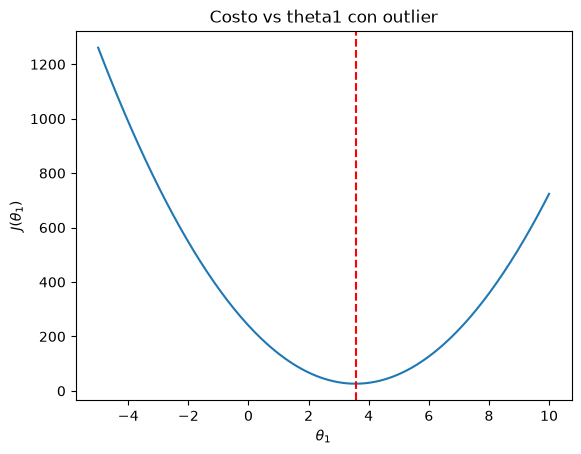

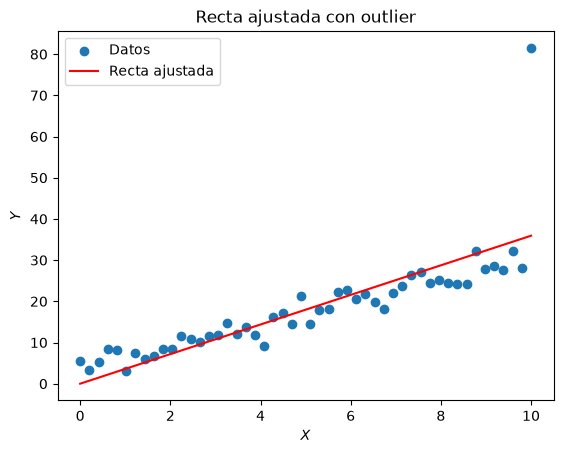

In [23]:
# ---------------------------------------------------------------------------
# Barrido de theta1 con theta0 = 0 fijo con Y_outlier
# ---------------------------------------------------------------------------
theta0_fijo = 0
thetas1 = np.linspace(-5, 10, 200)
costos = [funcion_costo(theta0_fijo, t1, X, Y_outlier) for t1 in thetas1]
theta1_optimo = thetas1[np.argmin(costos)]

plt.figure()
plt.plot(thetas1, costos)
plt.axvline(theta1_optimo, color="red", linestyle="--")
plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$J(\theta_1)$")
plt.title("Costo vs theta1 con outlier")
plt.show()

plt.figure()
plt.scatter(X, Y_outlier, label="Datos")
plt.plot(X, hipotesis(theta0_fijo, theta1_optimo, X), color="red", label="Recta ajustada")
plt.xlabel(r"$X$")
plt.ylabel(r"$Y$")
plt.title("Recta ajustada con outlier")
plt.legend()
plt.show()



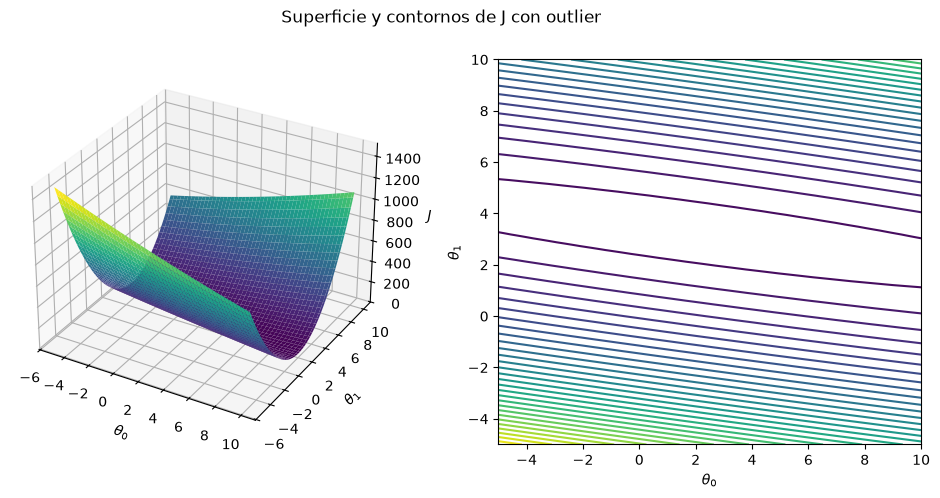

In [22]:
# ---------------------------------------------------------------------------
# Superficie y curvas de nivel de J(theta0, theta1) con outlier
# ---------------------------------------------------------------------------
t0_vals = np.linspace(-5, 10, 100)
t1_vals = np.linspace(-5, 10, 100)
T0, T1 = np.meshgrid(t0_vals, t1_vals)

J_vals = np.zeros_like(T0)
for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        J_vals[i, j] = funcion_costo(T0[i, j], T1[i, j], X, Y_outlier)

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot_surface(T0, T1, J_vals, cmap="viridis")
ax1.set_xlabel(r"$\theta_0$")
ax1.set_ylabel(r"$\theta_1$")
ax1.set_zlabel(r"$J$")

ax2 = fig.add_subplot(1, 2, 2)
ax2.contour(T0, T1, J_vals, levels=30, cmap="viridis")
ax2.set_xlabel(r"$\theta_0$")
ax2.set_ylabel(r"$\theta_1$")
plt.suptitle("Superficie y contornos de J con outlier")
plt.show()


### Sensibilidad del error cuadrático a valores atípicos

En las celdas 10 y 11, los datos contienen únicamente ruido moderado, por lo que la recta ajustada conserva una pendiente e intercepto cercanos a los valores originales. En cambio, en las celdas 14 y 15 se agrega un valor atípico extremo.

El error cuadrático es sensible a los valores atípicos porque eleva al cuadrado cada residuo:

\[
J(\theta_0,\theta_1)=\frac{1}{2m}\sum_{i=1}^{m}
\left(h_\theta(x_i)-y_i\right)^2
\]

Por ejemplo, un error de \(10\) aporta \(100\) al costo, mientras que un error de \(1\) aporta solamente \(1\). Así, aunque exista un solo valor atípico, puede dominar la función de costo.

Como consecuencia, la regresión modifica la pendiente y el intercepto para acercarse al punto extremo, alejándose de la tendencia principal de los datos. El costo mínimo aumenta y la recta representa peor a la mayoría de las observaciones. Sin embargo, \(J\) continúa siendo una función convexa con un único mínimo global; lo que cambia principalmente es la posición de dicho mínimo.

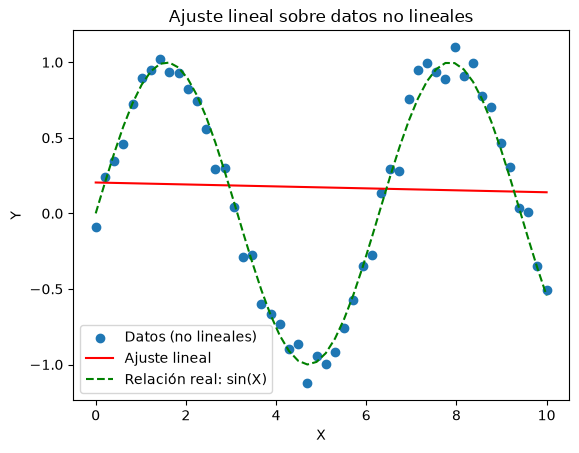

theta0 = 0.2043, theta1 = -0.0065
Costo J alcanzado = 0.22858


In [9]:
# ---------------------------------------------------------------------------
# Punto 8: datos no lineales
# ---------------------------------------------------------------------------
Y_no_lineal = np.sin(X) + np.random.normal(0, 0.1, size=len(X))

# Nota: como X va de 0 a 10 (sin normalizar), un alpha grande (p. ej. 0.5,
# usado en el punto 12 donde X está en [0,1]) diverge. Usamos uno más pequeño.
theta0_nl, theta1_nl = gradiente_descendente_regresion(X, Y_no_lineal, alpha=0.01)

plt.figure()
plt.scatter(X, Y_no_lineal, label="Datos (no lineales)")
plt.plot(X, hipotesis(theta0_nl, theta1_nl, X), color="red", label="Ajuste lineal")
plt.plot(X, np.sin(X), color="green", linestyle="--", label="Relación real: sin(X)")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Ajuste lineal sobre datos no lineales")
plt.legend()
plt.show()

costo_nl = funcion_costo(theta0_nl, theta1_nl, X, Y_no_lineal)
print(f"theta0 = {theta0_nl:.4f}, theta1 = {theta1_nl:.4f}")
print(f"Costo J alcanzado = {costo_nl:.5f}")

### Discusión: ¿minimizar J garantiza un modelo adecuado?

No. Minimizar la función de coste solo garantiza que, **dentro de la familia de
modelos elegida** (aquí, rectas), se encuentran los parámetros que mejor
ajustan los datos en el sentido de mínimos cuadrados. No garantiza que esa
familia de modelos sea la adecuada para describir la relación real.

En este caso los datos siguen `Y = sin(X) + ruido`, una relación claramente no
lineal. Aunque el gradiente descendente converge a un mínimo global de `J`
(la superficie sigue siendo un paraboloide convexo en `theta0, theta1`, sin
importar los datos), la recta resultante es un mal modelo: no captura la
periodicidad de la función seno y el costo final es sustancialmente mayor que
el obtenido con datos genuinamente lineales.

Esto ilustra que la convexidad de `J` asegura *encontrar el mejor ajuste
lineal posible*, pero la **elección del modelo** (lineal vs. no lineal) es un
supuesto previo que el algoritmo no cuestiona. Minimizar el costo es una
condición necesaria pero no suficiente para tener un buen modelo: hace falta
además verificar que la forma funcional elegida sea capaz de representar la
relación subyacente (por ejemplo, mediante el análisis de residuos o la
comparación visual con los datos).

### Punto 9: función de coste teórica

**Caso de un parámetro** (`theta1`, con `theta0 = 0` fijo, hipótesis
`h(x) = theta1 * x`):

$$
J(\theta_1) = \frac{1}{2m}\sum_{i=1}^{m}\left(\theta_1 x_i - y_i\right)^2
$$

Expandiendo, `J(theta1)` es un polinomio de segundo grado en `theta1`:

$$
J(\theta_1) = a\,\theta_1^2 + b\,\theta_1 + c,\qquad
a = \frac{1}{2m}\sum x_i^2 > 0
$$

Como el coeficiente cuadrático `a` es positivo, la gráfica de `J` es una
**parábola convexa** con un único mínimo, ubicado donde `dJ/dtheta1 = 0`.
Ese mínimo es el valor de `theta1` que hace que la recta pase lo más cerca
posible (en el sentido de mínimos cuadrados) de todos los puntos.

**Caso de dos parámetros** (`theta0`, `theta1`, hipótesis
`h(x) = theta0 + theta1*x`):

$$
J(\theta_0,\theta_1) = \frac{1}{2m}\sum_{i=1}^{m}\left(\theta_0 + \theta_1 x_i - y_i\right)^2
$$

En forma matricial, con `theta = [theta0, theta1]^T` y `X` la matriz de
diseño (una columna de unos y una columna con los `x_i`):

$$
J(\theta) = \frac{1}{2m}(X\theta - y)^T(X\theta - y)
$$

Esta es una **forma cuadrática** cuyo Hessiano es `(1/m) X^T X`, una matriz
semidefinida positiva. Por lo tanto `J(theta0, theta1)` es una superficie
convexa (un **paraboloide**): sus curvas de nivel son elipses concéntricas y
tiene un único mínimo global (único de verdad si `X^T X` es invertible).

**Interpretación del mínimo:** en ambos casos, el mínimo de `J` corresponde a
los parámetros que minimizan la suma de los residuos al cuadrado entre las
predicciones y los datos reales; es decir, la mejor recta posible bajo el
criterio de mínimos cuadrados. La convexidad garantiza que cualquier mínimo
local encontrado (por ejemplo, vía gradiente descendente) es también el
mínimo global, sin importar el punto de partida.

In [10]:
# ---------------------------------------------------------------------------
# Punto 10: gradiente descendente sobre f(x) = (x - 4)^2
# ---------------------------------------------------------------------------
f = lambda x: (x - 4) ** 2
df_dx = lambda x: 2 * (x - 4)

for alpha in [0.01, 0.1, 0.9]:
    w_min, hist = gradiente_descendente_1d(f, df_dx, w0=0, alpha=alpha)
    print(f"alpha={alpha}: minimo ~= {w_min:.5f} en {len(hist)} iteraciones")



alpha=0.01: minimo ~= 3.99511 en 333 iteraciones
alpha=0.1: minimo ~= 3.99966 en 43 iteraciones
alpha=0.9: minimo ~= 3.99996 en 53 iteraciones


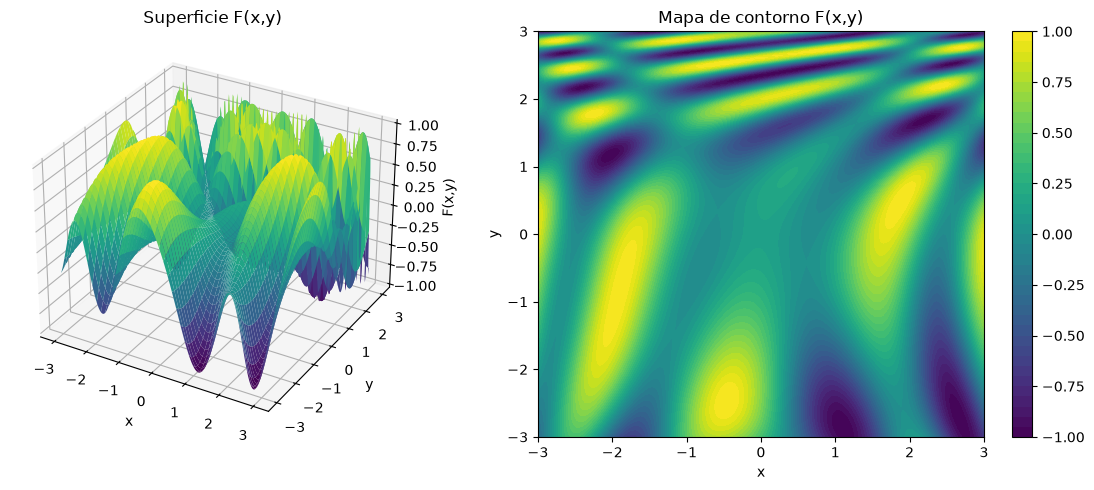

Inicio (-2, -2) -> minimo local en (-2.0586, -3.7668), F = -1.00000
Inicio (-2, 2) -> minimo local en (-2.4878, 1.8983), F = 0.30014
Inicio (0, 0) -> minimo local en (0.0000, 0.0000), F = 0.14112
Inicio (1.5, -1) -> minimo local en (1.0992, -2.8511), F = -1.00000
Inicio (2, 2) -> minimo local en (2.2013, 1.6868), F = -1.00000
Inicio (-1, 1.5) -> minimo local en (-2.0273, 1.1721), F = -1.00000

Mejor minimo encontrado: F(-2.0273, 1.1721) = -1.00000


In [11]:
# ---------------------------------------------------------------------------
# Punto 11: gradiente descendente sobre F(x, y)
# ---------------------------------------------------------------------------
def F(x, y):
    return np.sin(0.5 * x**2 - 0.25 * y**2 + 3) * np.cos(2 * x + 1 - np.exp(y))


def dFx(x, y):
    """Derivada parcial analitica dF/dx."""
    u = 0.5 * x**2 - 0.25 * y**2 + 3
    v = 2 * x + 1 - np.exp(y)
    return x * np.cos(u) * np.cos(v) - 2 * np.sin(u) * np.sin(v)


def dFy(x, y):
    """Derivada parcial analitica dF/dy."""
    u = 0.5 * x**2 - 0.25 * y**2 + 3
    v = 2 * x + 1 - np.exp(y)
    return -0.5 * y * np.cos(u) * np.cos(v) + np.exp(y) * np.sin(u) * np.sin(v)


# Grafica 3D y mapa de contorno de F
x_vals = np.linspace(-3, 3, 200)
y_vals = np.linspace(-3, 3, 200)
Xg, Yg = np.meshgrid(x_vals, y_vals)
Zg = F(Xg, Yg)

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot_surface(Xg, Yg, Zg, cmap="viridis")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("F(x,y)")
ax1.set_title("Superficie F(x,y)")

ax2 = fig.add_subplot(1, 2, 2)
cs = ax2.contourf(Xg, Yg, Zg, levels=40, cmap="viridis")
fig.colorbar(cs, ax=ax2)
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_title("Mapa de contorno F(x,y)")
plt.tight_layout()
plt.show()

# F no es convexa (tiene varios minimos locales), asi que se prueba el
# gradiente descendente desde varios puntos iniciales y nos quedamos con
# el mejor resultado encontrado.
puntos_iniciales = [(-2, -2), (-2, 2), (0, 0), (1.5, -1), (2, 2), (-1, 1.5)]
mejor_x, mejor_y, mejor_F = None, None, np.inf

for x0, y0 in puntos_iniciales:
    x_min, y_min = gradiente_descendente_2d(dFx, dFy, x0, y0, alpha=0.05)
    F_min = F(x_min, y_min)
    print(f"Inicio ({x0}, {y0}) -> minimo local en ({x_min:.4f}, {y_min:.4f}), F = {F_min:.5f}")
    if F_min < mejor_F:
        mejor_x, mejor_y, mejor_F = x_min, y_min, F_min

print(f"\nMejor minimo encontrado: F({mejor_x:.4f}, {mejor_y:.4f}) = {mejor_F:.5f}")



Gradiente descendente: 0.2102559626775552 0.1992766598325173
scikit-learn: 0.21024080611916707 0.19930494046342795
Diferencia |theta0|: 0.000015
Diferencia |theta1|: 0.000028


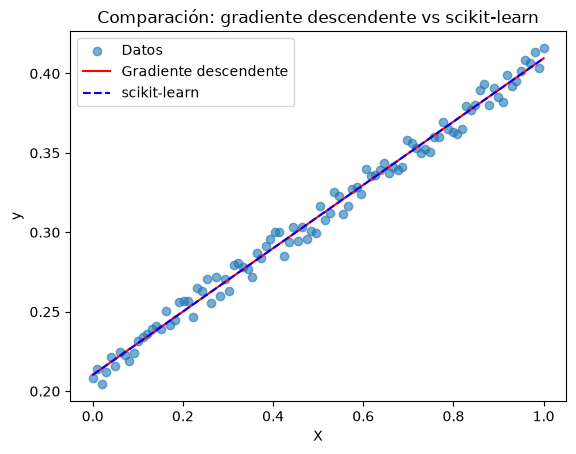

In [12]:
# ---------------------------------------------------------------------------
# Punto 12: regresion lineal completa + comparacion con scikit-learn
# ---------------------------------------------------------------------------
X_reg = np.linspace(0, 1, 100)
y_reg = 0.2 + 0.2 * X_reg + 0.02 * np.random.random(100)

theta0_gd, theta1_gd = gradiente_descendente_regresion(X_reg, y_reg)

modelo_sklearn = LinearRegression().fit(X_reg.reshape(-1, 1), y_reg)

print("Gradiente descendente:", theta0_gd, theta1_gd)
print("scikit-learn:", modelo_sklearn.intercept_, modelo_sklearn.coef_[0])

# Comparacion numerica
diferencia_theta0 = abs(theta0_gd - modelo_sklearn.intercept_)
diferencia_theta1 = abs(theta1_gd - modelo_sklearn.coef_[0])
print(f"Diferencia |theta0|: {diferencia_theta0:.6f}")
print(f"Diferencia |theta1|: {diferencia_theta1:.6f}")

# Grafica comparativa
plt.figure()
plt.scatter(X_reg, y_reg, alpha=0.6, label="Datos")
plt.plot(X_reg, hipotesis(theta0_gd, theta1_gd, X_reg), color="red", label="Gradiente descendente")
plt.plot(X_reg, modelo_sklearn.predict(X_reg.reshape(-1, 1)), color="blue", linestyle="--", label="scikit-learn")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Comparación: gradiente descendente vs scikit-learn")
plt.legend()
plt.show()


In [14]:
resultado = ajustar_regresion_lineal(X_reg, y_reg); print(resultado['theta0'], resultado['theta1'])

0.2102559626775552 0.1992766598325173
